# 04b - Phân tích sâu các cụm

# 04b - Semi-supervised experiments

Mục tiêu:
- Giả lập thiếu nhãn (10/20/30% labeled) cho đề tài phân lớp Bank Marketing
- So sánh hiệu năng supervised-only vs self-training (pseudo-label) theo PR-AUC/F1
- Vẽ learning curve theo % nhãn
- Phân tích rủi ro pseudo-label (nhóm tuổi/campaign)

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
from sklearn.semi_supervised import SelfTrainingClassifier

# Không phải tất cả kde hay gói matplotlib đều có style seaborn theo tên, dùng seaborn set để ổn định
sns.set(style='whitegrid')

DATA_PATH = os.path.join('..', 'data', 'processed', 'bank_clean.csv')
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=['y'])
y = df['y']

# 1) Train/test split giữ nguyên cho đánh giá.
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print('Train full', X_train_full.shape, 'Test', X_test.shape)

Train full (3390, 16) Test (1131, 16)


In [5]:
# 2) Chức năng tạo dữ liệu thiếu nhãn

def simulate_labeled_subset(X, y, labeled_ratio, random_state=42):
    rng = np.random.RandomState(random_state)
    n = len(y)
    labeled_count = int(np.round(n * labeled_ratio))
    idx = np.arange(n)
    rng.shuffle(idx)
    labeled_idx = idx[:labeled_count]
    unlabeled_idx = idx[labeled_count:]

    y_semi = y.copy().astype(float)
    y_semi.iloc[unlabeled_idx] = -1
    return y_semi

ratios = [0.1, 0.2, 0.3]

In [6]:
# 3) Đánh giá hàm

def report_performance(y_true, y_pred, y_score=None):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    a = accuracy_score(y_true, y_pred)
    pr_auc = None
    if y_score is not None:
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        pr_auc = auc(recall, precision)
    return {'accuracy': a, 'precision': p, 'recall': r, 'f1': f1, 'pr_auc': pr_auc}

In [10]:
# 4) Thử nghiệm với tỉ lệ nhãn khác nhau
results = []

for ratio in ratios:
    y_train_semi = simulate_labeled_subset(X_train_full, y_train_full, ratio, random_state=42)

    # Supervised chỉ dùng labeled
    labeled_mask = y_train_semi != -1
    X_labeled = X_train_full[labeled_mask]
    y_labeled = y_train_semi[labeled_mask]

    base = RandomForestClassifier(n_estimators=150, random_state=42)
    base.fit(X_labeled, y_labeled)
    y_pred_sup = base.predict(X_test)
    y_score_sup = base.predict_proba(X_test)[:, 1]
    sup_metrics = report_performance(y_test, y_pred_sup, y_score_sup)

    # Self-training pseudo-label
    self_trainer = SelfTrainingClassifier(estimator=RandomForestClassifier(n_estimators=150, random_state=42), threshold=0.8, verbose=False)
    self_trainer.fit(X_train_full, y_train_semi)
    y_pred_st = self_trainer.predict(X_test)
    y_score_st = self_trainer.predict_proba(X_test)[:, 1]
    st_metrics = report_performance(y_test, y_pred_st, y_score_st)

    results.append({
        'ratio': ratio,
        'method': 'supervised',
        **sup_metrics
    })
    results.append({
        'ratio': ratio,
        'method': 'self-training',
        **st_metrics
    })

results_df = pd.DataFrame(results)
results_df

,ratio,method,accuracy,precision,recall,f1,pr_auc
0,0.1,supervised,0.885942,0.518519,0.107692,0.178344,0.376831
1,0.1,self-training,0.886826,0.600000,0.046154,0.085714,0.329637
2,0.2,supervised,0.890363,0.615385,0.123077,0.205128,0.447781
3,0.2,self-training,0.885057,0.500000,0.061538,0.109589,0.380903
4,0.3,supervised,0.886826,0.517857,0.223077,0.311828,0.436593
5,0.3,self-training,0.887710,0.536585,0.169231,0.257310,0.446481


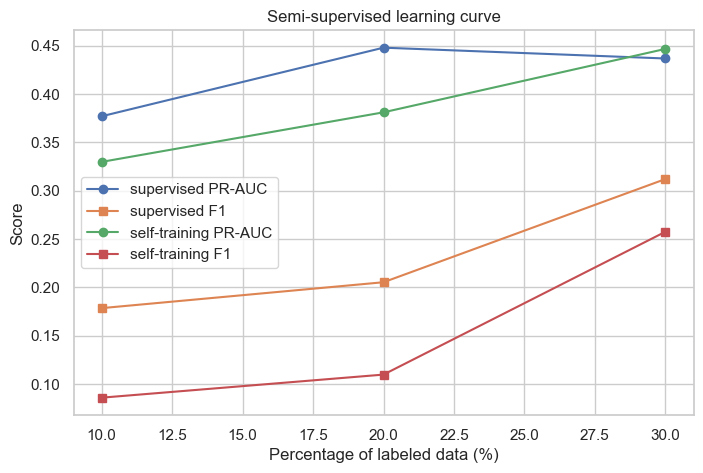

In [11]:
# 5) Vẽ learning curve theo % nhãn
plt.figure(figsize=(8, 5))
for method in ['supervised', 'self-training']:
    subset = results_df[results_df['method'] == method]
    plt.plot(subset['ratio']*100, subset['pr_auc'], marker='o', label=f'{method} PR-AUC')
    plt.plot(subset['ratio']*100, subset['f1'], marker='s', label=f'{method} F1')

plt.xlabel('Percentage of labeled data (%)')
plt.ylabel('Score')
plt.title('Semi-supervised learning curve')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# 6) Phân tích lỗi pseudo-label (ví dụ với tỷ lệ 20%)
ratio = 0.2
idx = results_df[(results_df['ratio']==ratio) & (results_df['method']=='self-training')].index

print('Self-training at 20% labeled:')
print(results_df.loc[idx])

# Dùng self_trainer từ vòng lặp trước có thể không tồn tại nếu đã re-ran một cell, nên huấn lại riêng:

y_train_semi = simulate_labeled_subset(X_train_full, y_train_full, ratio, random_state=42)
self_trainer = SelfTrainingClassifier(estimator=RandomForestClassifier(n_estimators=150, random_state=42), threshold=0.8, verbose=False)
self_trainer.fit(X_train_full, y_train_semi)

# Kiểm tra pseudo-label trên tập nhân nhãn ban đầu (unlabeled)
mask_unlabeled = y_train_semi == -1
pseudo_labels = self_trainer.predict(X_train_full[mask_unlabeled])

pseudo_stats = pd.Series(pseudo_labels).value_counts(normalize=True)
print('\nPseudo-label distribution on unlabeled:', pseudo_stats.to_dict())

Self-training at 20% labeled:
   ratio         method  accuracy  precision    recall        f1    pr_auc
3    0.2  self-training  0.885057        0.5  0.061538  0.109589  0.380903

Pseudo-label distribution on unlabeled: {0.0: 0.9933628318584071, 1.0: 0.00663716814159292}


## Kết luận tạm
- So sánh supervised vs self-training ở các mức label 10/20/30%.
- Nếu self-training cải thiện PR-AUC/F1, có thể sử dụng trong tình huống thiếu nhãn nghiêm trọng.
- Cần báo cáo thêm phân tích theo độ tuổi/campaign cho mẫu pseudo-label nhiễu.